<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> Credit Model

<font color='black'>

- Ivanna herrera Ibarra
- Ana Sofía Hinojosa Bale
- Luis Fernando Márquez Bañuelos

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
warnings.filterwarnings('ignore')

## <font color='cornflowerblue'> Functions

In [2]:
def curva_roc(probabilidades: np.ndarray, y_test: np.ndarray):
    fpr, tpr, thresholds = roc_curve(y_score=probabilidades, y_true=y_test)

    distances   = np.sqrt(fpr**2 + (1 - tpr)**2)
    best_idx    = np.argmin(distances)
    best_thr    = thresholds[best_idx]
    best_fpr    = fpr[best_idx]
    best_tpr    = tpr[best_idx]
    auc_score   = roc_auc_score(y_test, probabilidades)

    fig, ax = plt.subplots(figsize=(9, 5))

    # Área bajo la curva sombreada
    ax.fill_between(fpr, tpr, alpha=0.08, color='#2E86AB')

    ax.plot(fpr, tpr, color='#2E86AB', lw=2,
            label=f'AUC = {auc_score:.3f}')
    ax.plot([0, 1], [0, 1], color='#E84855', lw=1.5,
            linestyle='--', label='Random classifier')

    # Líneas guía al mejor threshold
    ax.plot([best_fpr, best_fpr], [0, best_tpr],
            color='#F4A261', lw=1, linestyle=':')
    ax.plot([0, best_fpr], [best_tpr, best_tpr],
            color='#F4A261', lw=1, linestyle=':')

    # Estrella
    ax.scatter(best_fpr, best_tpr, marker='*', s=400,
               color='#F4A261', zorder=5,
               label=f'Best threshold = {best_thr:.3f}\n'
                     f'FPR={best_fpr:.3f}  TPR={best_tpr:.3f}')

    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
    ax.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=11)
    ax.set_title('ROC Curve — Credit Default XGBoost',
                 fontsize=13, fontweight='bold', pad=12)
    ax.legend(fontsize=10, framealpha=0.9, loc='lower right')

    plt.tight_layout()
    plt.show()

    return best_thr

def outstanding_balance(principals: np.ndarray, annual_rate: float, n_months: int) -> np.ndarray:
    """
    Computes a random outstanding balance for each loan using the closed-form
    amortization formula.

    B_k = P * [(1+r)^n - (1+r)^k] / [(1+r)^n - 1]
    """
    r = annual_rate / 12
    n = n_months

    # Random month k in [25%, 75%] of the schedule for each client
    low  = round(n * 0.25)
    high = round(n * 0.75)
    k = np.random.randint(low, high, size=len(principals))

    factor_n = (1 + r) ** n
    factor_k = (1 + r) ** k

    # Balance after k months    
    balances = principals * (factor_n - factor_k) / (factor_n - 1)

    return np.round(balances, 2)

## <font color='cornflowerblue'> Data

In [3]:
data_train = pd.read_csv('data1_train.csv')
data_test = pd.read_csv('data2_test.csv')

## <font color='cornflowerblue'> Mortgage

In [4]:
# Simulate random loan amounts
monto_prestamo_train = np.random.randint(1_000_000, 5_000_000, len(data_train))
monto_prestamo_test  = np.random.randint(1_000_000, 5_000_000, len(data_test))

# Annual interest rate and loan term
tasa_interes_anual = 12.85 / 100
plazo_meses = 180

# Calculate outstanding debt for each client in train and test sets
outstanding_debt_train = outstanding_balance(monto_prestamo_train, tasa_interes_anual, plazo_meses)
outstanding_debt_test  = outstanding_balance(monto_prestamo_test,  tasa_interes_anual, plazo_meses)

# Estimation of LGD (Average is around 35% in Mexico for mortgage loans)
LGD_train = np.random.uniform(0.30, 0.40, len(data_train))
LGD_test  = np.random.uniform(0.30, 0.40, len(data_test))

In [5]:
# Add the simulated outstanding debt as a new feature to the datasets
data_train['outstanding_debt'] = outstanding_debt_train
data_test['outstanding_debt']   = outstanding_debt_test

# Add the simulated LGD as a new feature to the datasets
data_train['LGD'] = LGD_train
data_test['LGD']  = LGD_test

In [6]:
# Defining the target variable
target = 'default'

# Separating features and target variable
X_train = data_train.copy()
X_test = data_test.copy()

# Features for the model
X_train = X_train.drop(columns=['id', target, 'outstanding_debt', 'LGD'])
X_test = X_test.drop(columns=['id', target, 'outstanding_debt', 'LGD'])

# Target variable
y_train = data_train[target]
y_test = data_test[target]

X_train

,creditLimit,gender,edu,age,nDelay,billAmt1,billAmt2,billAmt3,billAmt4,billAmt5,billAmt6
0,4500,0,2,28,0,3915,3150,2475,2340,2385,2430
1,6000,0,2,24,0,2820,2700,2760,2400,2280,2280
2,3800,0,2,39,0,3572,3648,3762,2166,2204,2242
3,5500,1,1,27,0,5280,5445,5390,2585,2640,2695
4,18000,1,1,51,2,3780,3780,3780,1800,1620,720
...,...,...,...,...,...,...,...,...,...,...,...
1995,18000,1,1,34,0,180,180,180,180,180,180
1996,33300,1,1,34,0,333,333,2664,333,333,2331
1997,33000,1,2,35,0,18150,17820,17490,15510,15840,15840
1998,18200,1,1,36,0,182,364,0,182,182,182


## <font color='cornflowerblue'> Model: XGBoost

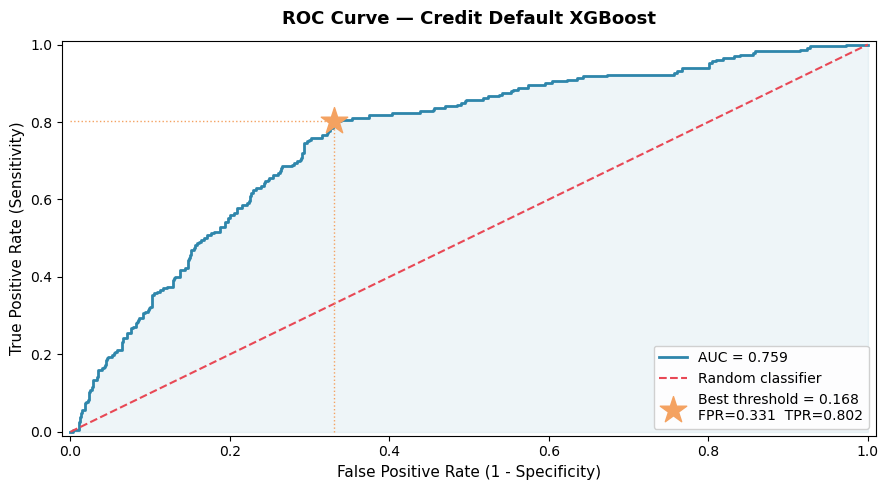

In [7]:
# XGBoost
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.01,
    min_child_weight=3,
    subsample=0.6,
    colsample_bytree=0.6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=0
)

# Predictions and probabilities
y_proba_log = model.predict_proba(X_test)[:, 1]
best_thr = curva_roc(y_proba_log, y_test)

In [8]:
# Add probabilities and calculate expected loss
data_test['default_proba'] = y_proba_log
data_test['EL_pct'] = data_test['default_proba'] * data_test['LGD']
data_test['EL_amount'] = data_test['default_proba'] * data_test['LGD'] * data_test['outstanding_debt']

# Results
portfolio = data_test['outstanding_debt'].sum()
expected_loss_portfolio = data_test['EL_amount'].sum()

print(f"Total Portfolio Outstanding Debt: ${portfolio:,.2f}")
print(f"Expected Loss for the Portfolio: ${expected_loss_portfolio:,.2f}")
print(f"Expected Loss as % of Portfolio: {expected_loss_portfolio / portfolio:.2%}")

Total Portfolio Outstanding Debt: $2,116,563,624.20
Expected Loss for the Portfolio: $154,614,620.69
Expected Loss as % of Portfolio: 7.30%


In [9]:
# Classify clients as predicted default (1) or non-default (0) based on the best threshold
data_test['model_prediction'] = (data_test['default_proba'] >= best_thr).astype(int)

# Computing actual loss based on model predictions. Where the model output was 0 (non-default) but the actual default was 1, we sum the outstanding debt to get the actual loss.
actual_loss = data_test[(data_test['model_prediction'] == 0) & data_test['default'] == 1]['outstanding_debt'].sum()
print(f"Actual Loss for the Portfolio: ${actual_loss:,.2f}")
print(f"Actual Loss as % of Portfolio: {actual_loss / portfolio:.2%}")

Actual Loss for the Portfolio: $105,010,901.94
Actual Loss as % of Portfolio: 4.96%


              precision    recall  f1-score   support

           0       0.92      0.67      0.77       768
           1       0.42      0.80      0.55       232

    accuracy                           0.70      1000
   macro avg       0.67      0.74      0.66      1000
weighted avg       0.80      0.70      0.72      1000



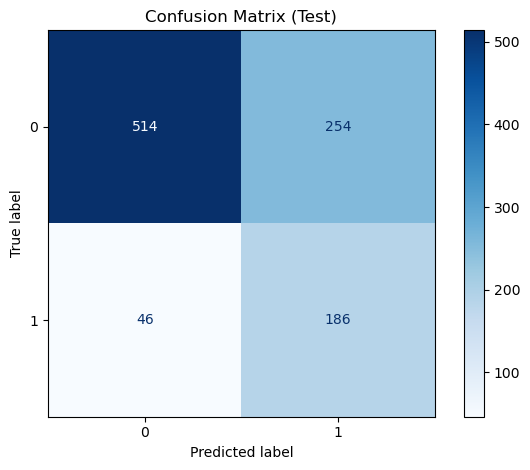

In [10]:
# Evaluation
print(classification_report(y_test, data_test['model_prediction']))

ConfusionMatrixDisplay.from_predictions(
    y_test, data_test['model_prediction'],
    display_labels=[0, 1],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()